# Sentiment Analysis using NLP Pipeline & ML Models
**Assignment: NLP-2 | End-to-End Sentiment Analysis System**

---
### Pipeline Overview
`Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison`

**Dataset:** IMDb Movie Reviews (50,000 reviews — Positive / Negative)  
**Models:** Logistic Regression, Naive Bayes, Decision Tree, Random Forest, XGBoost  
**Vectorizers:** Bag of Words (BoW) & TF-IDF

## 1. Import Required Libraries


In [14]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── NLP ─────────────────────────────────────────────────────────────────────
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# ── Feature Engineering ─────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)

# ── Download NLTK assets ─────────────────────────────────────────────────────
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 1. Load Data & understanding

In [15]:
# ── Load IMDb dataset via HuggingFace `datasets` (no Kaggle auth needed) ────
# Alternatively: df = pd.read_csv('IMDB Dataset.csv')  if downloaded from Kaggle

from datasets import load_dataset

raw = load_dataset('imdb')          # 25k train + 25k test
train_df = pd.DataFrame(raw['train'])
test_df  = pd.DataFrame(raw['test'])
df = pd.concat([train_df, test_df], ignore_index=True)

# Map numeric labels → string labels
df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})
df.drop(columns=['label'], inplace=True)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head(3)

Dataset shape : (50000, 2)
Columns       : ['text', 'sentiment']


,text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative


In [16]:
# ── Basic Statistics ─────────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(f'Total samples  : {len(df):,}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
print('=== Class Distribution ===')
print(df['sentiment'].value_counts())
print()
print('=== Sample Reviews ===')
for sent in ['positive', 'negative']:
    sample = df[df['sentiment'] == sent]['text'].iloc[0]
    print(f'[{sent.upper()}]: {sample[:200]}...')
    print()

=== Dataset Info ===
Total samples  : 50,000
Missing values : 0
Duplicate rows : 418

=== Class Distribution ===
sentiment
negative    25000
positive    25000
Name: count, dtype: int64

=== Sample Reviews ===
[POSITIVE]: Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo...

[NEGATIVE]: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...



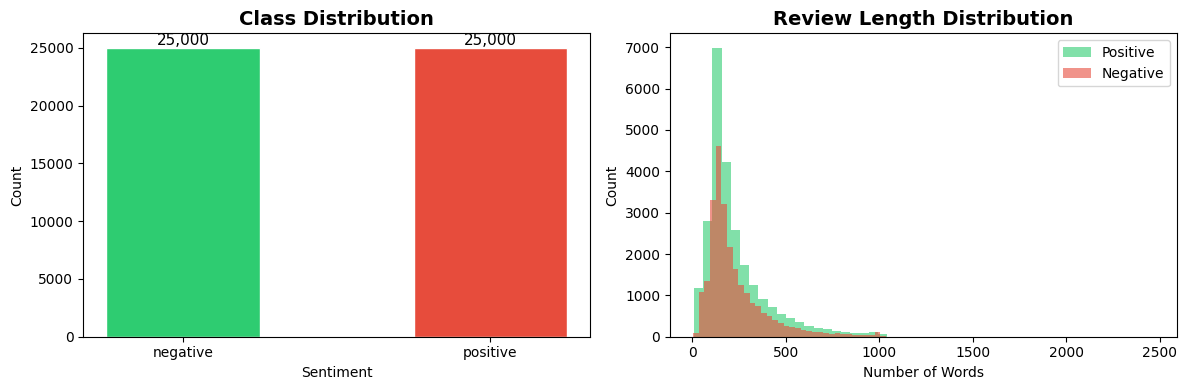


Avg review length: 231 words


In [17]:
# ── Visualise Class Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Review length distribution
df['review_length'] = df['text'].apply(lambda x: len(x.split()))
axes[1].hist(df[df['sentiment']=='positive']['review_length'], bins=50,
             alpha=0.6, label='Positive', color='#2ecc71')
axes[1].hist(df[df['sentiment']=='negative']['review_length'], bins=50,
             alpha=0.6, label='Negative', color='#e74c3c')
axes[1].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nAvg review length: {df["review_length"].mean():.0f} words')

---
## 2. NLP Preprocessing (Mandatory)

Steps applied in order:
1. Lowercasing
2. Remove URLs & HTML tags
3. Remove special characters & numbers
4. Remove punctuation
5. Tokenization
6. Remove stopwords
7. Lemmatization (+ optional Stemming comparison)

In [18]:
# ── Initialise tools ──────────────────────────────────────────────────────────
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()

# ────────────────────────────────────────────────────────────────────────────
# Reusable Preprocessing Functions
# ────────────────────────────────────────────────────────────────────────────

def to_lowercase(text: str) -> str:
    """Step 1 – Convert all characters to lowercase."""
    return text.lower()

def remove_urls(text: str) -> str:
    """Step 2a – Remove URLs (http/https/www)."""
    return re.sub(r'https?://\S+|www\.\S+', ' ', text)

def remove_html(text: str) -> str:
    """Step 2b – Strip HTML tags (common in IMDb/Amazon datasets)."""
    return re.sub(r'<.*?>', ' ', text)

def remove_special_chars(text: str) -> str:
    """Step 3 – Remove non-alphabetic characters and numbers."""
    return re.sub(r'[^a-z\s]', ' ', text)

def remove_punctuation(text: str) -> str:
    """Step 4 – Remove punctuation marks."""
    return text.translate(str.maketrans('', '', string.punctuation))

def tokenize(text: str) -> list:
    """Step 5 – Tokenize text into a list of word tokens."""
    return word_tokenize(text)

def remove_stopwords(tokens: list) -> list:
    """Step 6 – Remove common English stopwords."""
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

def lemmatize_tokens(tokens: list) -> list:
    """Step 7a – Lemmatize tokens (preferred: keeps real words)."""
    return [lemmatizer.lemmatize(t) for t in tokens]

def stem_tokens(tokens: list) -> list:
    """Step 7b – Stem tokens (aggressive; produces word roots)."""
    return [stemmer.stem(t) for t in tokens]

# ────────────────────────────────────────────────────────────────────────────
# Master pipeline function
# ────────────────────────────────────────────────────────────────────────────

def preprocess(text: str, use_stemming: bool = False) -> str:
    """
    Full NLP preprocessing pipeline.
    Parameters
    ----------
    text         : raw input string
    use_stemming : if True, use stemming; else use lemmatization

    Returns
    -------
    Cleaned, preprocessed string ready for vectorisation.
    """
    text = to_lowercase(text)
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_special_chars(text)
    text = remove_punctuation(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens) if use_stemming else lemmatize_tokens(tokens)
    return ' '.join(tokens)

print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


In [19]:
# ── Demo: Before vs After ─────────────────────────────────────────────────────
sample_raw = df['text'].iloc[0]
sample_clean = preprocess(sample_raw)

print('=== RAW TEXT (first 300 chars) ===')
print(sample_raw[:300])
print()
print('=== PREPROCESSED TEXT (first 300 chars) ===')
print(sample_clean[:300])

=== RAW TEXT (first 300 chars) ===
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

=== PREPROCESSED TEXT (first 300 chars) ===
rented curious yellow video store controversy surrounded first released also heard first seized custom ever tried enter country therefore fan film considered controversial really see plot centered around young swedish drama student named lena want learn everything life particular want focus attentio


In [20]:
# ── Apply preprocessing to entire dataset (takes ~2-3 minutes for 50k rows) ─
print('Preprocessing dataset... (this may take a few minutes)')
df['cleaned_text'] = df['text'].apply(preprocess)
print(f'✅ Done! Preprocessed {len(df):,} reviews.')
df[['text', 'cleaned_text', 'sentiment']].head(3)

Preprocessing dataset... (this may take a few minutes)
✅ Done! Preprocessed 50,000 reviews.


,text,cleaned_text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curious yellow video store controversy ...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...,negative
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...,negative


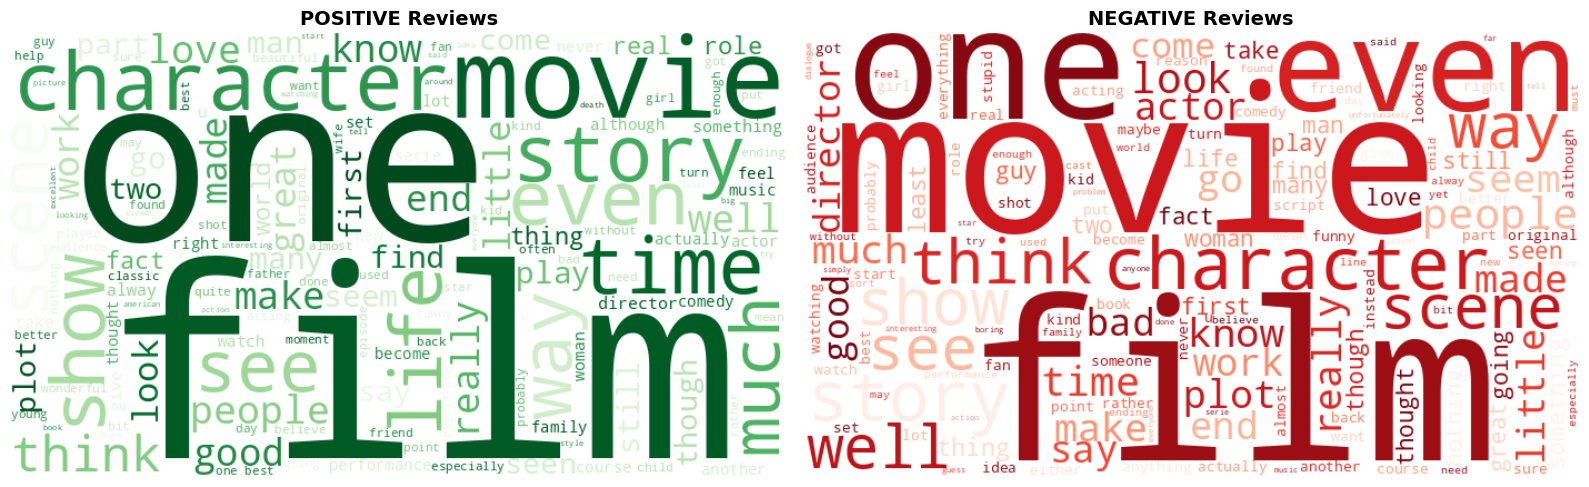

In [21]:
# ── Word Cloud: Positive vs Negative ────────────────────────────────────────
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, sentiment, color in zip(axes,
                                    ['positive', 'negative'],
                                    ['Greens', 'Reds']):
        text_blob = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
        wc = WordCloud(width=700, height=400, colormap=color,
                       background_color='white', max_words=150).generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{sentiment.upper()} Reviews', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('WordCloud not installed — skipping visualisation.')

---
## 3. Feature Engineering

We convert text to numerical representations using:
- **Bag of Words (BoW)** – raw term frequency counts
- **TF-IDF** – term frequency × inverse document frequency (penalises common words)

In [22]:
# ── Train / Test Split (before vectorisation to prevent data leakage) ────────
X = df['cleaned_text']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')

Training samples : 40,000
Test samples     : 10,000
Class balance (train): {1: 20000, 0: 20000}


In [23]:
# ── Bag of Words Vectoriser ────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=10000,     # keep top 10k most frequent terms
    ngram_range=(1, 2),     # unigrams + bigrams for richer context
    min_df=2                # ignore terms that appear in < 2 documents
)
X_train_bow = bow_vectorizer.fit_transform(X_train)  # fit on train only!
X_test_bow  = bow_vectorizer.transform(X_test)

print(f'BoW feature matrix (train): {X_train_bow.shape}')
print(f'BoW feature matrix (test) : {X_test_bow.shape}')
print(f'Sample features: {bow_vectorizer.get_feature_names_out()[:10].tolist()}')

BoW feature matrix (train): (40000, 10000)
BoW feature matrix (test) : (10000, 10000)
Sample features: ['aaron', 'abandon', 'abandoned', 'abbott', 'abc', 'ability', 'able', 'able get', 'able see', 'aboard']


In [24]:
# ── TF-IDF Vectoriser ─────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True       # apply log(1+tf) smoothing
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f'TF-IDF feature matrix (train): {X_train_tfidf.shape}')
print(f'TF-IDF feature matrix (test) : {X_test_tfidf.shape}')

TF-IDF feature matrix (train): (40000, 10000)
TF-IDF feature matrix (test) : (10000, 10000)


---
## 4. Model Building & Training

We train **5 models** on both BoW and TF-IDF features:
1. Logistic Regression
2. Naive Bayes (Multinomial)
3. Decision Tree
4. Random Forest
5. XGBoost

In [25]:
# ── Model Definitions ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=42),

    'Naive Bayes': MultinomialNB(
        alpha=1.0),        # Laplace smoothing

    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, min_samples_split=10, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=42)
}

print(f'✅ {len(models)} models configured.')# ── Training & Evaluation Helper ─────────────────────────────────────────────
def evaluate_model(model, X_tr, X_te, y_tr, y_te, vectorizer_name):
    """
    Trains a model and returns a dict of evaluation metrics.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    return {
        'Vectorizer' : vectorizer_name,
        'Accuracy'   : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision'  : round(precision_score(y_te, y_pred) * 100, 2),
        'Recall'     : round(recall_score(y_te, y_pred) * 100, 2),
        'F1 Score'   : round(f1_score(y_te, y_pred) * 100, 2),
        '_y_pred'    : y_pred   # stored for confusion matrix, hidden in display
    }

print('✅ Evaluation helper ready.')

✅ 5 models configured.
✅ Evaluation helper ready.


In [26]:
# ── Train all models on both vectorisers ─────────────────────────────────────
results = []          # list of result dicts
trained  = {}         # store trained models for later inspection

vectorizer_sets = [
    ('BoW',    X_train_bow,   X_test_bow),
    ('TF-IDF', X_train_tfidf, X_test_tfidf),
]

import copy, time

for vec_name, X_tr, X_te in vectorizer_sets:
    print(f'\n── Vectorizer: {vec_name} ──────────────────────────────')
    for model_name, model in models.items():
        t0 = time.time()
        m  = copy.deepcopy(model)          # fresh copy for each run
        res = evaluate_model(m, X_tr, X_te, y_train, y_test, vec_name)
        res['Model'] = model_name
        elapsed = round(time.time() - t0, 1)
        results.append(res)
        trained[f'{model_name}_{vec_name}'] = (m, res['_y_pred'])
        print(f'  {model_name:<22} Acc={res["Accuracy"]}%  F1={res["F1 Score"]}%  ({elapsed}s)')

print('\n✅ All models trained and evaluated!')


── Vectorizer: BoW ──────────────────────────────
  Logistic Regression    Acc=88.06%  F1=88.11%  (4.0s)
  Naive Bayes            Acc=86.06%  F1=86.18%  (0.0s)
  Decision Tree          Acc=74.22%  F1=76.55%  (9.8s)
  Random Forest          Acc=83.6%  F1=84.32%  (8.8s)
  XGBoost                Acc=83.39%  F1=84.02%  (6.3s)

── Vectorizer: TF-IDF ──────────────────────────────
  Logistic Regression    Acc=89.91%  F1=90.02%  (0.2s)
  Naive Bayes            Acc=86.97%  F1=87.14%  (0.0s)
  Decision Tree          Acc=74.32%  F1=76.69%  (14.2s)
  Random Forest          Acc=83.4%  F1=84.13%  (12.1s)
  XGBoost                Acc=83.23%  F1=83.82%  (115.8s)

✅ All models trained and evaluated!


## 5. Model Evaluation and comparison


In [27]:
# ── Results DataFrame ─────────────────────────────────────────────────────────
display_cols = ['Model', 'Vectorizer', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
results_df   = pd.DataFrame(results)[display_cols]
results_df   = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('=== Model Comparison Table (sorted by F1 Score) ===')
results_df.style.background_gradient(subset=['Accuracy','Precision','Recall','F1 Score'],
                                      cmap='YlGn')

=== Model Comparison Table (sorted by F1 Score) ===


,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,TF-IDF,89.910000,89.010000,91.060000,90.020000
1,Logistic Regression,BoW,88.060000,87.760000,88.460000,88.110000
2,Naive Bayes,TF-IDF,86.970000,86.000000,88.320000,87.140000
3,Naive Bayes,BoW,86.060000,85.450000,86.920000,86.180000
4,Random Forest,BoW,83.600000,80.770000,88.200000,84.320000
5,Random Forest,TF-IDF,83.400000,80.600000,87.980000,84.130000
6,XGBoost,BoW,83.390000,80.970000,87.300000,84.020000
7,XGBoost,TF-IDF,83.230000,80.960000,86.900000,83.820000
8,Decision Tree,TF-IDF,74.320000,70.210000,84.480000,76.690000
9,Decision Tree,BoW,74.220000,70.200000,84.160000,76.550000


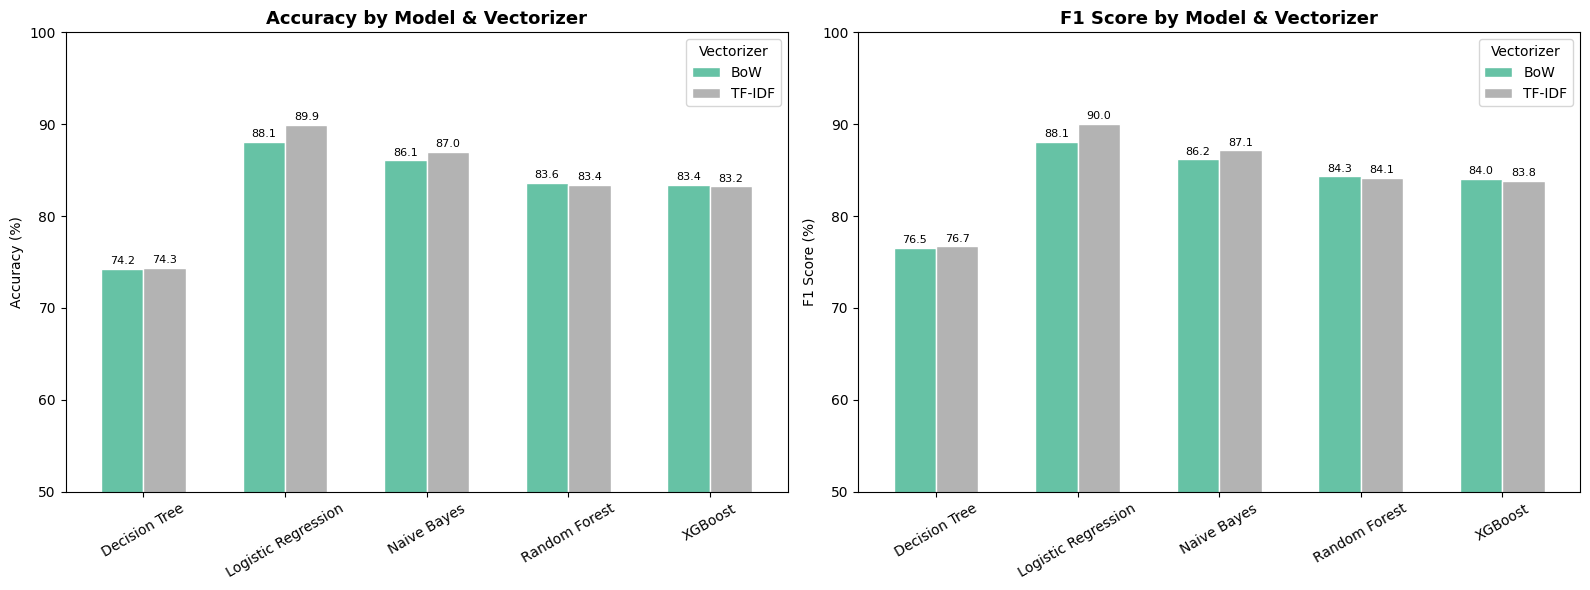

In [28]:
# ── Bar Chart: Accuracy & F1 by Model + Vectorizer ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
    pivot = results_df.pivot(index='Model', columns='Vectorizer', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.6)
    ax.set_title(f'{metric} by Model & Vectorizer', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(f'{metric} (%)')
    ax.set_ylim(50, 100)
    ax.legend(title='Vectorizer')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

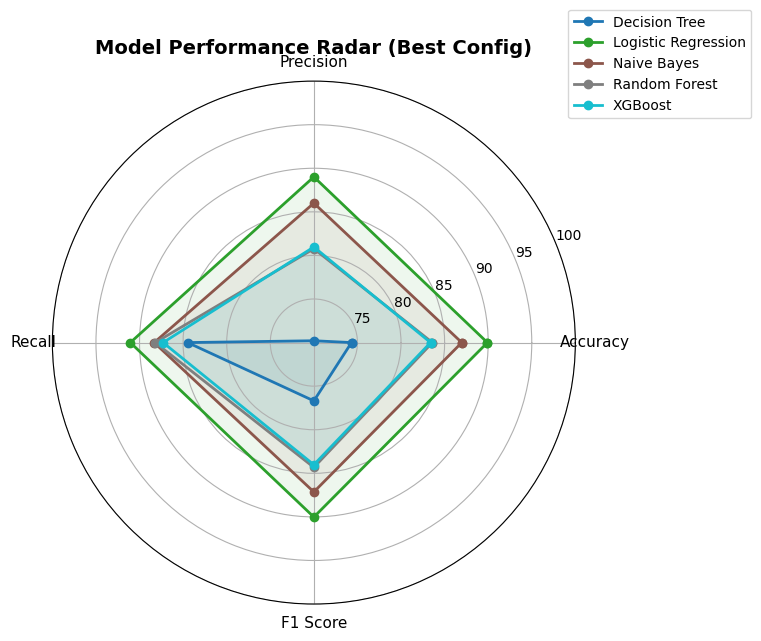

In [29]:
# ── Radar / Spider Chart: All 4 metrics for best config of each model ─────────
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as pe

# Best result per model (highest F1)
best_per_model = results_df.groupby('Model').apply(
    lambda g: g.loc[g['F1 Score'].idxmax()]).reset_index(drop=True)

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N         = len(metrics)
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles   += angles[:1]          # close the loop
colors    = plt.cm.tab10s(np.linspace(0, 1, len(best_per_model)))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

for (_, row), color in zip(best_per_model.iterrows(), colors):
    values  = row[metrics].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=11)
ax.set_ylim(70, 100)
ax.set_title('Model Performance Radar (Best Config)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

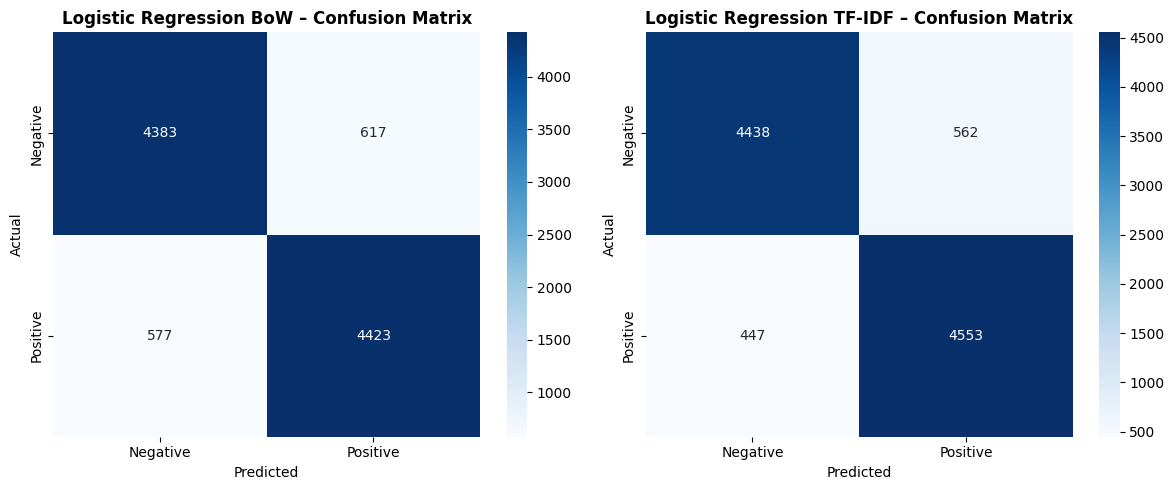

In [30]:
# ── Confusion Matrices for best model per vectorizer ─────────────────────────
# Identify overall best model
best_row = results_df.iloc[0]
best_key = f"{best_row['Model']}_{best_row['Vectorizer']}"
_, best_y_pred = trained[best_key]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (key, (model, y_pred)) in zip(
        axes,
        [(f"{results_df.iloc[0]['Model']}_BoW",    trained.get(f"{results_df.iloc[0]['Model']}_BoW",    (None, None))),
         (f"{results_df.iloc[0]['Model']}_TF-IDF", trained.get(f"{results_df.iloc[0]['Model']}_TF-IDF", (None, None)))]):

    if y_pred is None:
        continue
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{key.replace("_", " ")} – Confusion Matrix',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Detailed Classification Report for best model ────────────────────────────
print(f'=== Classification Report: {best_row["Model"]} + {best_row["Vectorizer"]} ===')
print(classification_report(y_test, best_y_pred,
                             target_names=['Negative', 'Positive']))

=== Classification Report: Logistic Regression + TF-IDF ===
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [32]:
print('=== Final Performance Summary (sorted by F1) ===')
print(results_df.to_string(index=False))

=== Final Performance Summary (sorted by F1) ===
              Model Vectorizer  Accuracy  Precision  Recall  F1 Score
Logistic Regression     TF-IDF     89.91      89.01   91.06     90.02
Logistic Regression        BoW     88.06      87.76   88.46     88.11
        Naive Bayes     TF-IDF     86.97      86.00   88.32     87.14
        Naive Bayes        BoW     86.06      85.45   86.92     86.18
      Random Forest        BoW     83.60      80.77   88.20     84.32
      Random Forest     TF-IDF     83.40      80.60   87.98     84.13
            XGBoost        BoW     83.39      80.97   87.30     84.02
            XGBoost     TF-IDF     83.23      80.96   86.90     83.82
      Decision Tree     TF-IDF     74.32      70.21   84.48     76.69
      Decision Tree        BoW     74.22      70.20   84.16     76.55


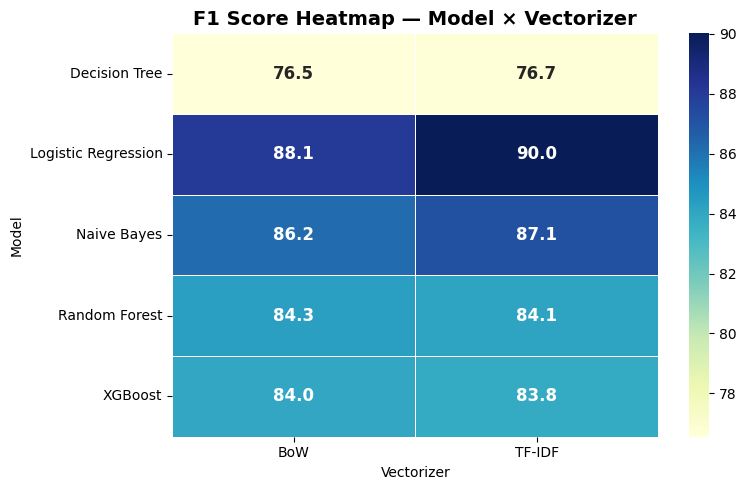

In [33]:
# ── Final visual: Metrics heatmap ─────────────────────────────────────────────
pivot_f1 = results_df.pivot(index='Model', columns='Vectorizer', values='F1 Score')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('F1 Score Heatmap — Model × Vectorizer', fontsize=14, fontweight='bold')
plt.ylabel('Model')
plt.xlabel('Vectorizer')
plt.tight_layout()
plt.savefig('f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ── Load best model for inference ─────────────────────────────────────────────
best_model, _ = trained[best_key]
best_vec      = tfidf_vectorizer   # or bow_vectorizer depending on best_row['Vectorizer']

def predict_sentiment(text: str) -> str:
    """Predict sentiment for a single raw review text."""
    cleaned  = preprocess(text)
    features = best_vec.transform([cleaned])
    pred     = best_model.predict(features)[0]
    proba    = best_model.predict_proba(features)[0]
    label    = '✅ POSITIVE' if pred == 1 else '❌ NEGATIVE'
    conf     = max(proba) * 100
    return f'{label}  (confidence: {conf:.1f}%)'

# Test on custom sentences
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me hooked.",
    "Terrible film. Complete waste of time. The plot made no sense and the acting was awful.",
    "It was okay, nothing special. Some scenes were good but the ending was disappointing.",
]

print('=== Custom Predictions ===')
for review in test_reviews:
    print(f'Review : {review[:80]}...')
    print(f'Prediction : {predict_sentiment(review)}')
    print()

=== Custom Predictions ===
Review : This movie was absolutely fantastic! The acting was superb and the story kept me...
Prediction : ✅ POSITIVE  (confidence: 96.0%)

Review : Terrible film. Complete waste of time. The plot made no sense and the acting was...
Prediction : ❌ NEGATIVE  (confidence: 100.0%)

Review : It was okay, nothing special. Some scenes were good but the ending was disappoin...
Prediction : ❌ NEGATIVE  (confidence: 97.1%)

